In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Load data
X_train_smote = np.load('../Data/processed/X_train_smote.npy')
y_train_smote = np.load('../Data/processed/y_train_smote.npy')
X_train       = np.load('../Data/processed/X_train.npy')
y_train       = np.load('../Data/processed/y_train.npy')

LABEL_NAMES = {
    0: 'N\n(Normal)',
    1: 'S\n(Supravent.)',
    2: 'V\n(Ventric.)',
    3: 'F\n(Fusion)'
}
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Count
before = Counter(y_train.tolist())
after  = Counter(y_train_smote.tolist())
classes = sorted(before.keys())

before_counts = [before[c] for c in classes]
after_counts  = [after[c]  for c in classes]
labels        = [LABEL_NAMES[c] for c in classes]

print('Before SMOTE:', dict(before))
print('After  SMOTE:', dict(after))
print(f'\nBefore total: {sum(before_counts):,}')
print(f'After  total: {sum(after_counts):,}')

Before SMOTE: {0: 63243, 1: 1945, 2: 5065, 3: 561}
After  SMOTE: {0: 63243, 1: 63243, 2: 63243, 3: 63243}

Before total: 70,814
After  total: 252,972


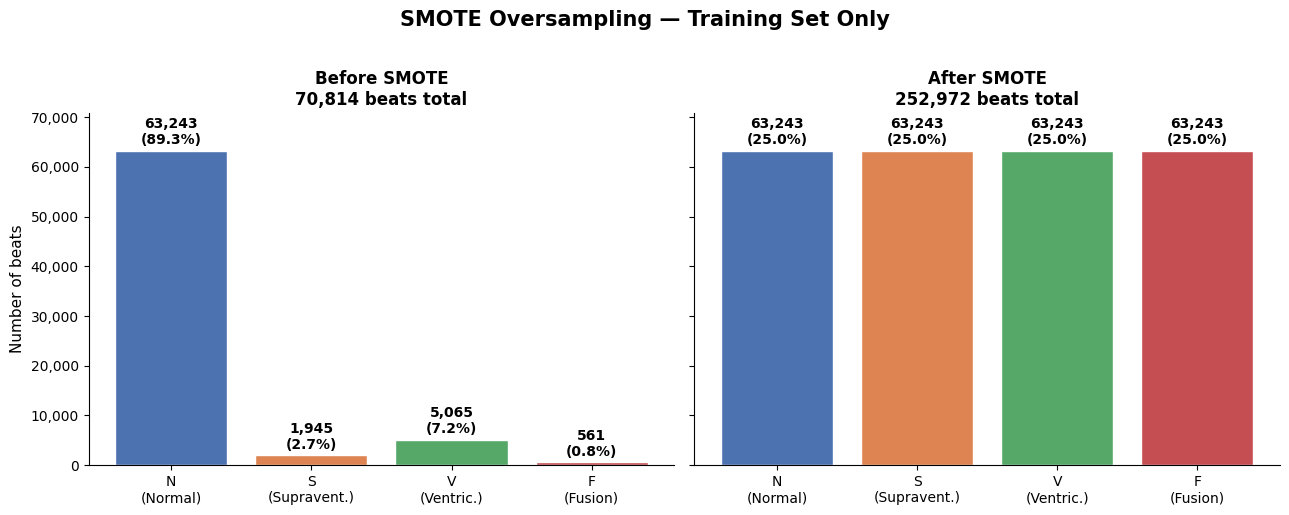


Saved: smote_before_after.png


In [5]:
# Side-by-side bar chart (matches y-axis scale so the contrast is visible)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle('SMOTE Oversampling — Training Set Only',
             fontsize=15, fontweight='bold', y=1.02)

ymax = max(after_counts) * 1.12

# --- Before ---
ax = axes[0]
bars = ax.bar(labels, before_counts, color=COLORS, edgecolor='white', linewidth=1)
ax.set_title(f'Before SMOTE\n{sum(before_counts):,} beats total',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Number of beats', fontsize=11)
ax.set_ylim(0, ymax)
for bar, v in zip(bars, before_counts):
    pct = v / sum(before_counts) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ymax*0.01,
            f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(labelsize=10)

# --- After ---
ax = axes[1]
bars = ax.bar(labels, after_counts, color=COLORS, edgecolor='white', linewidth=1)
ax.set_title(f'After SMOTE\n{sum(after_counts):,} beats total',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, ymax)
for bar, v in zip(bars, after_counts):
    pct = v / sum(after_counts) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ymax*0.01,
            f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('smote_before_after.png', dpi=200, bbox_inches='tight')
plt.show()
print('\nSaved: smote_before_after.png')